<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Inside the Latent Space</b>
</h1>
<div style="font-family:'Times New Roman';">
The VAE works, so now the interesting part. Walking between two digits, drawing the whole 2d latent map, doing arithmetic on codes, and checking what the beta knob does to the tradeoff between rebuilding and sampling.
</div>

## training two models

one with a 2 dimensional latent so the space can be drawn directly, and one with 16 for the better quality experiments. wrapping the training in a function since i need it several times with diffrent settings.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

torch.manual_seed(0)

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
X = torch.tensor(mnist.data[:10000] / 255.0, dtype=torch.float32)
y = mnist.target[:10000].astype(int)

def train_vae(L, beta=1.0, epochs=60, seed=0):
    torch.manual_seed(seed)
    enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 2*L))
    dec = nn.Sequential(nn.Linear(L, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=1e-3)

    for epoch in range(epochs):
        perm = torch.randperm(len(X))
        for i in range(0, len(X), 256):
            xb = X[perm[i:i+256]]
            mu, logvar = enc(xb).chunk(2, dim=1)
            z = mu + torch.exp(0.5*logvar) * torch.randn_like(mu)
            out = dec(z)

            recon = F.binary_cross_entropy(out, xb, reduction='sum') / len(xb)
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(xb)
            loss = recon + beta * kl

            opt.zero_grad(); loss.backward(); opt.step()

    return enc, dec, recon.item(), kl.item()

enc16, dec16, r16, k16 = train_vae(16)
enc2,  dec2,  r2,  k2  = train_vae(2)
print("latent 16 : recon", round(r16,1), " kl", round(k16,1))
print("latent  2 : recon", round(r2,1),  " kl", round(k2,1))

latent 16 : recon 88.7  kl 25.9
latent  2 : recon 157.8  kl 4.9


16 dimensions rebuilds much better, as expected, there is simply more room to store detail.

## walking from one digit to another

taking the codes of two real images and stepping along the straight line between them. if the space is properly filled then every point on that line should decode into something that still looks like a digit.

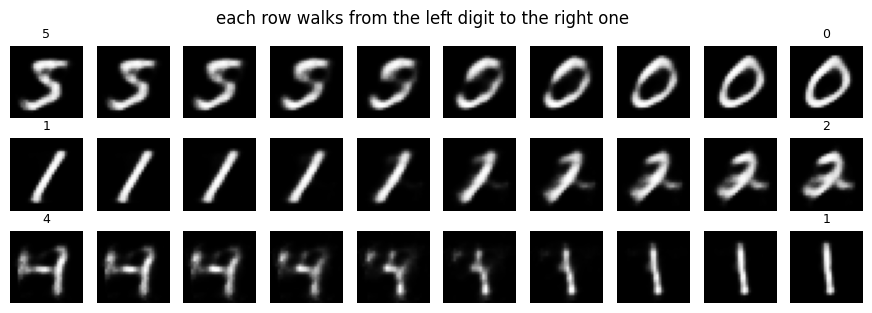

In [10]:
def interpolate(enc, dec, i, j, steps=10):
    with torch.no_grad():
        mu, _ = enc(X[[i, j]]).chunk(2, dim=1)
        alphas = torch.linspace(0, 1, steps).unsqueeze(1)
        z = (1 - alphas) * mu[0] + alphas * mu[1]      # straight line between the two codes
        return dec(z)

pairs = [(0, 1), (3, 5), (2, 8)]

fig, ax = plt.subplots(len(pairs), 10, figsize=(11, 3.4))
for r, (i, j) in enumerate(pairs):
    imgs = interpolate(enc16, dec16, i, j)
    for k in range(10):
        ax[r,k].imshow(imgs[k].reshape(28,28), cmap='gray'); ax[r,k].axis('off')
    ax[r,0].set_title(str(y[i]), fontsize=9)
    ax[r,9].set_title(str(y[j]), fontsize=9)
plt.suptitle('each row walks from the left digit to the right one')
plt.show()

every step in between is still a plausible digit, it morphs smoothly rather than jumping. that is the filled space the KL term bought us. the same walk on the plain autoencoder from notebook 01 would pass through the empty regions and produce blobs.

## the whole 2d space at once

with L = 2 i can lay out a grid over the latent space and decode every point. since the codes follow a standard normal, taking the grid from the normal quantiles covers exactly where the data lives.

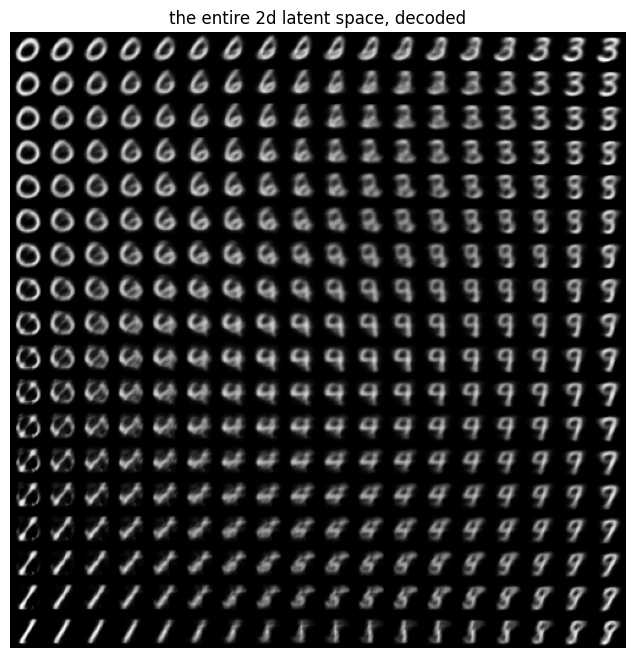

In [3]:
from scipy.stats import norm

n = 18
grid = norm.ppf(np.linspace(0.02, 0.98, n))     # quantiles of N(0,1), not a plain linspace
canvas = np.zeros((28*n, 28*n))

with torch.no_grad():
    for i, yi in enumerate(grid[::-1]):
        row = torch.tensor([[xi, yi] for xi in grid], dtype=torch.float32)
        imgs = dec2(row).reshape(-1, 28, 28).numpy()
        for j in range(n):
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = imgs[j]

plt.figure(figsize=(8,8))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title('the entire 2d latent space, decoded')
plt.show()

this is the picture that made the idea click for me. digit types occupy connected regions, and neighbouring regions are the ones that look alike, the 4s sit next to the 9s and the 3s next to the 8s. nothing told the model which digit is which, it never saw a label.

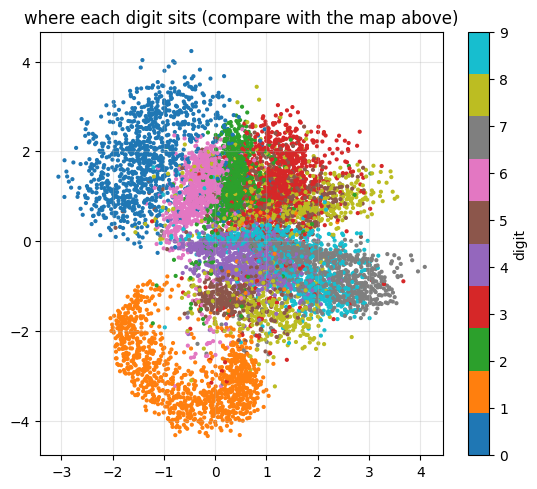

In [4]:
with torch.no_grad():
    mu2, _ = enc2(X).chunk(2, dim=1)

plt.figure(figsize=(6.5,5.5))
sc = plt.scatter(mu2[:,0], mu2[:,1], c=y, cmap='tab10', s=4)
plt.colorbar(sc, label='digit')
plt.title('where each digit sits (compare with the map above)')
plt.grid(alpha=.3)
plt.show()

## arithmetic on codes

the classic word2vec style test. if the space is organised then averaging the codes of many 3s should give a generic 3, and directions in the space should mean something.

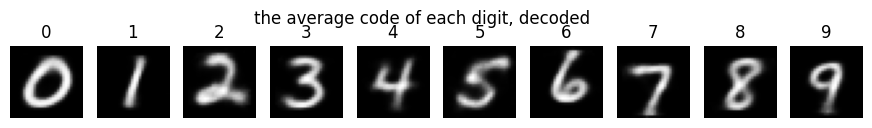

In [5]:
with torch.no_grad():
    mu_all, _ = enc16(X).chunk(2, dim=1)

def mean_code(digit):
    return mu_all[y == digit].mean(dim=0)

fig, ax = plt.subplots(1, 10, figsize=(11,1.5))
with torch.no_grad():
    for d in range(10):
        img = dec16(mean_code(d).unsqueeze(0))
        ax[d].imshow(img.reshape(28,28), cmap='gray'); ax[d].set_title(d); ax[d].axis('off')
plt.suptitle('the average code of each digit, decoded')
plt.show()

clean prototypes, and again no labels were used in training, i only used them here to group the codes afterwards.

now a direction. taking `mean(1) - mean(7)` as a vector and adding it to other digits to see if it carries a consistent meaning.

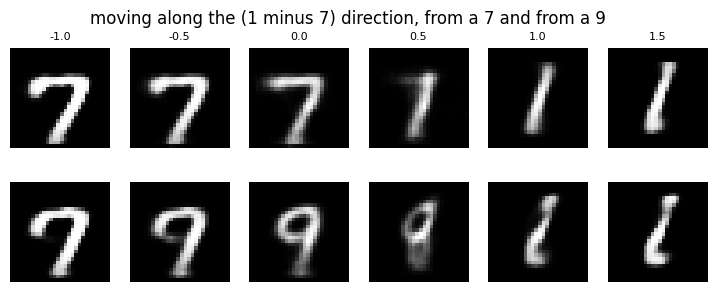

In [6]:
direction = mean_code(1) - mean_code(7)

fig, ax = plt.subplots(2, 6, figsize=(9,3.2))
with torch.no_grad():
    for col, scale in enumerate(np.linspace(-1, 1.5, 6)):
        for row, start in enumerate([mean_code(7), mean_code(9)]):
            img = dec16((start + scale * direction).unsqueeze(0))
            ax[row,col].imshow(img.reshape(28,28), cmap='gray'); ax[row,col].axis('off')
            if row == 0:
                ax[row,col].set_title(round(float(scale), 2), fontsize=8)
plt.suptitle('moving along the (1 minus 7) direction, from a 7 and from a 9')
plt.show()

this worked better than i expected. both rows end up at a 1. the 7 straightens out cleanly, and the 9 also lands on a thin slanted stroke by the time the scale reaches 1.0.

the difference is the journey. the 7 morphs smoothly the whole way, while the 9 goes through a mess at scale 0.5, a half closed blob that is not any digit. so the direction does carry real `1 ness`, but the straight line from a 9 passes through a bad region on the way.

also the result keeps the slant of where it started, so it is not a clean identity swap, its more like adding 1 ness on top of what was already there.

## the beta knob

multiplying the KL term by a factor. `beta` bigger than 1 forces the space to look more like a standard normal, at the cost of reconstruction.

In [7]:
results = {}
for beta in [0.5, 1.0, 4.0]:
    e, d, r, k = train_vae(16, beta=beta, epochs=40)
    results[beta] = (e, d, r, k)
    print("beta", str(beta).ljust(4), " recon", round(r, 1), " kl", round(k, 1))

beta 0.5   recon 82.4  kl 29.0


beta 1.0   recon 87.2  kl 22.1


beta 4.0   recon 124.0  kl 8.3


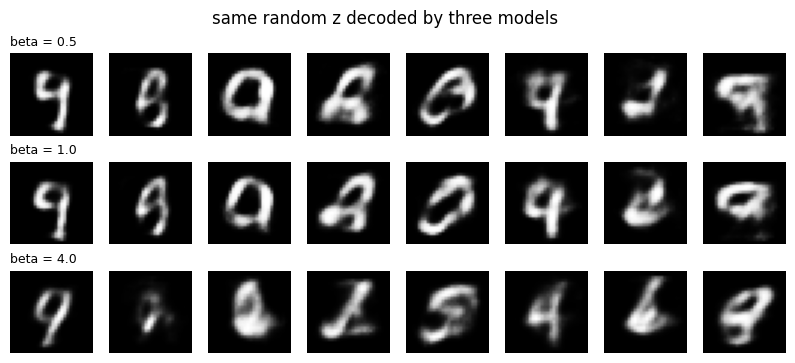

In [8]:
fig, ax = plt.subplots(3, 8, figsize=(10,4))
torch.manual_seed(5)
z_fixed = torch.randn(8, 16)

for row, beta in enumerate([0.5, 1.0, 4.0]):
    e, d, r, k = results[beta]
    with torch.no_grad():
        imgs = d(z_fixed)
    for i in range(8):
        ax[row,i].imshow(imgs[i].reshape(28,28), cmap='gray'); ax[row,i].axis('off')
    ax[row,0].set_ylabel('beta ' + str(beta))
    ax[row,0].set_title('beta = ' + str(beta), loc='left', fontsize=9)
plt.suptitle('same random z decoded by three models')
plt.show()

### what i learned

- interpolating between two digits stays on real looking digits the whole way, thats the filled space the KL term paid for
- the 2d latent map is the picture worth keeping. digit regions are connected and lookalike digits are neighbours, and no labels were ever used
- averaging the codes of each digit gives clean prototypes
- latent arithmetic worked better than i expected, `mean(1) - mean(7)` turned both a 7 and a 9 into a 1, though the 9 went through a blob on the way
- beta trades reconstruction against a tidy latent space, and the numbers move exactly as expected: beta 0.5 gives recon 82 and kl 29, beta 4 gives recon 124 and kl 8